**Name:** Kristhian André Oliveira Aguilar

**Student ID:** 298976

Transform this notebook into a technical report on experiments using a **VAE (Variational Autoencoder)** architecture.

* Add comments to the different code blocks, explaining the purpose of each one.
* Explain how the **latent space** is constructed. Show different results for various configurations.
* Change the model's training parameters.
* Propose ways to evaluate the quality of the generated samples.

# Attr2Font (Dataset)

* **Github:** [https://github.com/hologerry/Attr2Font](https://github.com/hologerry/Attr2Font)
* **Dataset:** [https://drive.google.com/file/d/1TTqAklfsAp6KOPxCVl2jktH8kN4lEmI_/view](https://drive.google.com/file/d/1TTqAklfsAp6KOPxCVl2jktH8kN4lEmI_/view)

# Introduction

Generative models have shown remarkable success in creating realistic data across various domains, including images, text, and audio. A Variational Autoencoder (VAE) is a type of unsupervised generative model that learns a probabilistic mapping from a high-dimensional data space (like images) to a lower-dimensional, continuous latent space. This latent space captures the core variations in the data. By sampling from this space, the VAE's decoder can generate new data points that resemble the original training data.

The goal of this project is to implement and train a VAE on a dataset of font glyphs to:

1. Learn a compressed, meaningful representation (latent space) of font characters.

2. Generate novel and plausible font glyphs.

3. Investigate how architectural choices and training hyperparameters affect the generation quality.

# Methods

### Importing Libs

 This cell installs the required Python packages for the project.

 - **`scikit-learn`** and **`scikit-image`**: Used for calculating image-based evaluation metrics like SSIM and PSNR.

 - **`torch-fidelity`**: A library specifically for calculating generative model metrics like Fréchet Inception Distance (FID).

In [1]:
!pip install scikit-learn scikit-image torch-fidelity -q

 This block imports all the necessary modules for the project.



 - **`torch`** and its submodules (`nn`, `optim`, `F`) are the core components for building and training the VAE in PyTorch.

 - **`torchvision`** provides utilities for handling image datasets and transformations.

 - **`tqdm`** is used to create progress bars for training loops, making them more informative.

 - **`matplotlib`** and **`numpy`** are used for plotting results and numerical operations.

 - **`sklearn`**, **`skimage`**, and **`torch_fidelity`** are imported for model evaluation.

 - Standard libraries like **`os`**, **`shutil`**, and **`datetime`** are used for file and directory management.

In [2]:
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets,transforms
from torchvision.utils import save_image
from tqdm.notebook import tqdm
import os
import shutil
import pandas as pd
from datetime import datetime
import subprocess
import random
random.seed(5) # for reproducibility
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format='svg'
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np

from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from torch_fidelity import calculate_metrics
from PIL import Image

### Data

The project utilizes the Attr2Font dataset, which contains a large collection of character glyphs. The following code block handles the download and extraction of this dataset. It creates the necessary directory structure (data, results, models) to organize the project files.

In [3]:
# This block automates the dataset download and setup process.
if not os.path.exists("explor_all") and not os.path.exists("data/Fonts"):
    # Download the dataset from Google Drive using gdown
    # Unzip the downloaded file
    if not os.path.exists("explor_all.zip"):
        subprocess.run(
            ["gdown", "--id", "1TTqAklfsAp6KOPxCVl2jktH8kN4lEmI_"], check=True
        )
        subprocess.run(["unzip", "explor_all.zip"], check=True)

    # Create directories for storing data, results, and trained models
    os.makedirs("data", exist_ok=True)
    os.makedirs("results", exist_ok=True)
    os.makedirs("models", exist_ok=True)

    # Move the extracted image folder to the designated data directory
    shutil.move("explor_all/image", "data/Fonts")

    print("✅ Dataset downloaded, extracted, and moved successfully!")
else:
    print("⚠️ Skipped: either zip file or folder already exists.")

⚠️ Skipped: either zip file or folder already exists.


 Before training, the images undergo a series of transformations:



 1. **Grayscale Conversion**: The images are converted to a single channel (grayscale) as color is not relevant for glyph shape.



 2. **Resizing**: All images are resized to a uniform dimension of 50×50 pixels to ensure consistent input size for the model.



 3. **Tensor Conversion**: The processed images are converted into PyTorch tensors, with pixel values scaled to the `[0,1]` range.



 This code also sets some initial hyperparameters and visualizes a sample image before and after the transformations to verify the process.

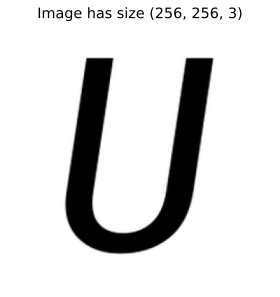

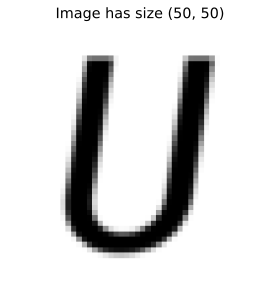

In [4]:
epochs=5
batch_size=128
torch.manual_seed(17)

path='data/Fonts'
train_path = 'data/trainFonts'
val_path = 'data/valFonts'

def show_img(img):
    img = img.permute(1, 2, 0)
    if img.shape[2]==1:
        img = img.view(img.shape[0], img.shape[1])
    plt.title(f'Image has size {img.cpu().numpy().shape}')
    plt.imshow(img,cmap='gray')
    plt.axis('off')
    plt.show()

transforms_all = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=50),
    transforms.ToTensor()
])

dummy_batch = torch.utils.data.DataLoader(
    datasets.ImageFolder(path,transform=transforms.ToTensor()),
    batch_size=1, shuffle=True
)

for batch in dummy_batch:
  original_image=batch[0][0]
  show_img(original_image)
  show_img(transforms_all(transforms.ToPILImage()(original_image)))
  break

### Splitting Data into Training and Validation Sets

 To properly train and evaluate the model, the dataset is split into training and validation sets. This allows us to monitor the model's performance on unseen data and prevent overfitting.


 A subset of the available font folders (`num_folders = 134`) is used for faster experimentation. For each selected font folder, 20 images are randomly chosen and moved to the validation set, while the remaining images are used for training.

In [5]:
import os
import shutil
import random
from tqdm import tqdm

folders = os.listdir(path)
print(f"Total font folders available: {len(folders)}")

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)

# Podemos limitar em num_folders a quantidade total de pasta que iremos trabalhar
num_folders = 134
count_folders = 1

for folder in tqdm(folders):
    if count_folders <= num_folders:
        os.makedirs(f"{train_path}/{folder}", exist_ok=True)
        os.makedirs(f"{val_path}/{folder}", exist_ok=True)
        images = os.listdir(f"{path}/{folder}")
        random.shuffle(images)

        for image in images[:20]:
            shutil.copy(
                f"{path}/{folder}/{image}", f"{val_path}/{folder}/{image}"
            )
        for image in images[20:]:
            shutil.copy(
                f"{path}/{folder}/{image}", f"{train_path}/{folder}/{image}"
            )
    count_folders += 1

# Count number of folders
train_folders = len(os.listdir(train_path))
val_folders = len(os.listdir(val_path))

# Count number of images
train_images = sum(
    len(files) for _, _, files in os.walk(train_path)
)
val_images = sum(
    len(files) for _, _, files in os.walk(val_path)
)

print(f"Number of training folders: {train_folders}")
print(f"Number of validation folders: {val_folders}")
print(f"Number of training images: {train_images}")
print(f"Number of validation images: {val_images}")

Total font folders available: 1116


100%|██████████| 1116/1116 [00:00<00:00, 2837.96it/s]

Number of training folders: 134
Number of validation folders: 134
Number of training images: 5628
Number of validation images: 2680


### VAE implementation

Our VAE is composed of two main parts: an encoder and a decoder. Both are implemented using simple fully-connected (linear) layers.

- Encoder: Takes a flattened image (50 x 50 by default) as input and maps it to a latent distribution. Instead of outputting a single latent vector, it outputs two vectors: a mean vector ($\mu$) and a log-variance vector ($\log{\sigma^2}$).

- Decoder: Takes a single point sampled from the latent distribution and attempts to reconstruct the original input image.

In [6]:
class VAE(nn.Module):
    def __init__(self, z_dim=32, hidden_dim = 1000, img_size = 50):
        super(VAE, self).__init__()

        # The dimension of the latent space. This is a key hyperparameter.
        self.z_dim = z_dim
        self.img_size = img_size

        # The dimension of the hidden layers in both the encoder and decoder.
        self.hidden_dim = hidden_dim
        self.img_flat_size = img_size * img_size

        # --- ENCODER ---
        # It maps the input image to the parameters of the latent distribution.
        # Layer 1: Flattens the image and maps it to an intermediate representation.
        self.fc1 = nn.Linear(self.img_flat_size, self.hidden_dim)
        # Layer 2a: Maps the intermediate representation to the mean (mu) of the latent distribution.
        self.fc21 = nn.Linear(self.hidden_dim, self.z_dim)
        # Layer 2b: Maps the intermediate representation to the log-variance (logvar) of the latent distribution.
        self.fc22 = nn.Linear(self.hidden_dim, self.z_dim)

        # --- DECODER ---
        # It maps a point from the latent space back to the original image space.
        # Layer 3: Maps the latent vector z to an intermediate representation.
        self.fc3 = nn.Linear(self.z_dim, self.hidden_dim)
        # Layer 4: Maps the intermediate representation back to the flattened image size.
        self.fc4 = nn.Linear(self.hidden_dim, self.img_flat_size)

    def encode(self, x):
        # The encode function passes the input through the encoder layers.
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1) # Returns mu and logvar

    def reparameterize(self, mu, logvar):
        # This function implements the reparameterization trick.
        # It allows us to backpropagate through a random sampling operation.
        std = torch.exp(0.5*logvar) # Calculate standard deviation from log-variance
        eps = torch.randn_like(std) # Sample from a standard normal distribution
        return mu + eps*std # Combine them to get a sample z from N(mu, std)

    def decode(self, z):
        # The decode function passes the latent vector z through the decoder layers.
        h3 = F.relu(self.fc3(z))
        # The output is passed through a sigmoid function to ensure pixel values are between 0 and 1.
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        # The full forward pass of the VAE.
        # 1. Encode the input image to get mu and logvar.
        mu, logvar = self.encode(x.view(-1, self.img_flat_size))
        # 2. Sample a latent vector z using the reparameterization trick.
        z = self.reparameterize(mu, logvar)
        # 3. Decode z to reconstruct the image.
        return self.decode(z), mu, logvar

#### Constructing the Latent Space

The core idea of a VAE is to learn a distribution for each input image in the latent space, rather than just a single point. This is what makes it generative. The encoder network outputs the parameters ($μ$, $\log{σ^2}$) that define a Gaussian distribution $\mathcal{N}(\mu,\sigma^2I)$.

The reparameterization trick ($z=\mu+\epsilon⋅\sigma$, where $\epsilon∼\mathcal{N}(0,I)$) is a crucial step. It allows us to sample a latent vector $z$ from this learned distribution in a way that allows gradients to flow back through the network during training. This is essential for optimization.

The Kullback-Leibler (KL) divergence part of the loss function (explained below) pushes the learned distributions for all images to be close to a standard normal distribution $\mathcal{N}(0,I)$. This regularizes the latent space, ensuring it is smooth and continuous. This smoothness means that points that are close to each other in the latent space will decode to visually similar images, enabling meaningful interpolation and generation.

The dimensionality of the latent space (`z_dim`) is a critical hyperparameter:

- Low `z_dim` (ex. 2, 8): Forces the model into a very tight bottleneck. It must learn to encode only the most essential features (ex. basic stroke shapes). Generated samples might lack diversity and fine detail. A 2D space is great for visualization, as you can plot the "manifold" of generated fonts.

- Medium `z_dim` (ex. 32, 64): A good balance. The model has enough capacity to capture rich features and stylistic variations, leading to higher-quality reconstructions and more diverse generated samples.

- High `z_dim` (ex. 256): Gives the model high capacity. This can lead to near-perfect reconstructions but the model may just memorize the data, hurting its ability to generate novel, coherent samples.

A similar interpretation applies to the `hidden_dim` parameter, which controls the size of the hidden layers in both the encoder and decoder networks. Larger hidden dimensions allow the model to learn more complex mappings but also increase the risk of overfitting.

For this report, we initially use `z_dim=32` and `hidden_dim=1000`, which provides a good balance between model capacity and generalization.

#### VAE Loss Function

 The VAE's loss function is composed of two distinct terms that balance two competing objectives:



 1.  **Reconstruction Loss (BCE)**: This term is the Binary Cross-Entropy between the original image and the reconstructed image. It measures how well the decoder is able to recreate the input from the latent representation. Minimizing this loss pushes the model to learn a latent space that captures all the information needed for reconstruction.



 2.  **Kullback-Leibler (KL) Divergence (KLD)**: This term is a regularizer. It measures how much the distribution learned by the encoder (for a given image) diverges from a standard normal distribution ($\mathcal{N}(0, 1)$). By minimizing the KLD, we force the encoder to place all learned distributions close to the origin in a compact, continuous manner. This structuring of the latent space is what enables smooth interpolation and meaningful generation.



 The total loss is the sum of these two terms, forcing the model to find a latent representation that is both informative (for good reconstruction) and well-structured (for good generation).

In [7]:
def loss_function(recon_x, x, mu, logvar):
    img_flat_dim = x.shape[-1] * x.shape[-2]
    # Use binary_cross_entropy for reconstruction loss
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, img_flat_dim), reduction='sum')
    # KL divergence to regularize the latent space
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

### Training Framework

To organize the training and evaluation process, we define a set of helper functions. This modular approach makes the code cleaner and easier to manage.

 -   **`train_one_epoch`**: Handles the training loop for a single epoch. It iterates over the training data, computes the loss, performs backpropagation, and updates the model's weights.

 -   **`evaluate_one_epoch`**: Evaluates the model's performance on the validation dataset. It calculates the validation loss and saves a sample of image reconstructions to visually track progress.

 -   **`sample_latent_space`**: Demonstrates the generative capability of the VAE. It samples random points from a standard normal distribution, passes them through the decoder, and saves the resulting generated images.

 -   **`plot_losses`**: A utility function to plot the training and validation loss curves over epochs, which helps in diagnosing issues like overfitting.

In [8]:
def train_one_epoch(model, optimizer, train_loader, device, epoch, img_size):
    """Trains the model for one epoch."""
    model.train()
    train_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch:03d}', leave=False)
    for data, _ in progress_bar:
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        progress_bar.set_postfix({'training_loss': f'{loss.item() / len(data):.3f}'})
    
    avg_loss = train_loss / len(train_loader.dataset)
    tqdm.write(f'Epoch {epoch:03d} | Average Training Loss: {avg_loss:.3f}')
    return avg_loss

def evaluate_one_epoch(
    model, val_loader, device, epoch, batch_size, img_size,
    results_dir, fixed_batch=None
):
    """Evaluates the model and saves a reconstruction sample from either 
       the provided fixed_batch or the first batch of val_loader."""
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for i, (data, _) in enumerate(val_loader):
            data = data.to(device)

            # 🔹 Use the SAME fixed_images if provided
            if fixed_batch is not None:
                data = fixed_batch.to(device)

            recon_batch, mu, logvar = model(data)
            val_loss += loss_function(recon_batch, data, mu, logvar).item()

            if i == 0 or fixed_batch is not None:
                n = min(data.size(0), 16)
                comparison = torch.cat([
                    data[:n],
                    recon_batch.view(-1, 1, img_size, img_size)[:n]
                ])
                save_image(
                    comparison.cpu(),
                    os.path.join(results_dir, f'reconstruction_{epoch:03d}.png'),
                    nrow=n
                )

            # If fixed batch is used, only run once
            if fixed_batch is not None:
                break

    avg_loss = val_loss / len(val_loader.dataset)
    tqdm.write(f'\t\t====> Validation Loss: {avg_loss:.3f}')
    return avg_loss

def sample_latent_space(model, device, epoch, z_dim, img_size, results_dir):
    """Generates and saves samples from the latent space."""
    with torch.no_grad():
        sample = torch.randn(64, z_dim).to(device)
        generated = model.decode(sample).cpu()
        save_image(generated.view(64, 1, img_size, img_size), os.path.join(results_dir, f'sample_{epoch:03d}.png'))

def plot_losses(train_losses, val_losses, output_dir):
    """Plots and saves the training and validation loss curves."""
    plt.figure()

    if len(train_losses) > 0:
        train_epochs, train_vals = zip(*train_losses)
        plt.plot(train_epochs, train_vals, label="Training Loss")

    if len(val_losses) > 0:
        val_epochs, val_vals = zip(*val_losses)
        plt.plot(val_epochs, val_vals, label="Validation Loss")

    plt.title("Training & Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    out_path = os.path.join(output_dir, "loss_curve.png")
    plt.savefig(out_path)
    plt.show()
    print(f"📉 Loss curves saved to {out_path}")

 This next block of code orchestrates the entire experiment.

 -   **`create_experiment_dirs`**: Sets up a unique, timestamped directory for each experiment run to store results, models, and plots, preventing them from overwriting each other.

 -   **`create_dataloaders`**: Prepares the PyTorch `DataLoader` objects for the training and validation sets, which handle batching, shuffling, and data transformation.

 -   **`training_loop`**: The main driver of the training process. It iterates through the specified number of epochs, calling the `train_one_epoch` and `evaluate_one_epoch` functions, saving model checkpoints, and logging losses.

 -   **`run_experiment`**: The top-level function that takes a configuration dictionary, sets up the experiment, initializes the model and optimizer, and starts the training loop. This makes it easy to run multiple experiments with different hyperparameters.

In [9]:
def create_experiment_dirs(config):
    config_name = (
        f"z_dim_{config['z_dim']}_hidden_dim_{config['hidden_dim']}"
        f"_lr_{config['lr']}_bs_{config['batch_size']}_epochs_{config['epochs']}"
    )
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    experiment_dir = os.path.join(config["base_output_dir"], timestamp, config_name)
    results_dir = os.path.join(experiment_dir, "results")
    models_dir = os.path.join(experiment_dir, "models")
    os.makedirs(results_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"🚀 Starting Experiment: {config_name}")
    print(f"   Outputs will be saved to: {experiment_dir}")
    print(f"{'='*60}\n")

    return config_name, experiment_dir, results_dir, models_dir


def create_dataloaders(config):
    transforms_set = transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize(size=config["img_size"]),
            transforms.ToTensor(),
        ]
    )
    train_loader = torch.utils.data.DataLoader(
        datasets.ImageFolder(config["train_path"], transform=transforms_set),
        batch_size=config["batch_size"],
        shuffle=True,
    )
    val_loader = torch.utils.data.DataLoader(
        datasets.ImageFolder(config["val_path"], transform=transforms_set),
        batch_size=config["batch_size"],
        shuffle=True,
    )
    return train_loader, val_loader


def validation_step(model, val_loader, config, epoch, results_dir, models_dir, best_val_loss):
    val_loss = evaluate_one_epoch(
        model,
        val_loader,
        config["device"],
        epoch,
        config["batch_size"],
        config["img_size"],
        results_dir,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_path = os.path.join(models_dir, "best_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"🌟 New best model at epoch {epoch}! (val_loss={val_loss:.4f})")

    return val_loss, best_val_loss


def training_loop(
    model,
    optimizer,
    train_loader,
    val_loader,
    config,
    results_dir,
    models_dir,
    experiment_dir,
):
    """Full training + validation loop"""
    # Store (epoch, loss) pairs
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    val_interval = config.get("val_interval", 1)

    for epoch in range(1, config["epochs"] + 1):
        # --- Train ---
        train_loss = train_one_epoch(
            model, optimizer, train_loader, config["device"], epoch, config["img_size"]
        )
        train_losses.append((epoch, train_loss))

        # --- Validate periodically ---
        if epoch % val_interval == 0 or epoch == config["epochs"]:
            val_loss, best_val_loss = validation_step(
                model, val_loader, config, epoch, results_dir, models_dir, best_val_loss
            )
            val_losses.append((epoch, val_loss))

        # --- Save progress (as 2-column arrays: epoch, loss) ---
        np.savetxt(
            os.path.join(experiment_dir, "train_losses.txt"),
            np.array(train_losses),
            fmt="%d %.6f",
            header="epoch train_loss",
        )
        np.savetxt(
            os.path.join(experiment_dir, "val_losses.txt"),
            np.array(val_losses),
            header="epoch val_loss",
        )

        # --- Save samples ---
        sample_latent_space(
            model,
            config["device"],
            epoch,
            config["z_dim"],
            config["img_size"],
            results_dir,
        )

        # --- Save periodic checkpoints ---
        if epoch % config["save_interval"] == 0 or epoch == config["epochs"]:
            torch.save(
                model.state_dict(),
                os.path.join(models_dir, f"model_epoch_{epoch:03d}.pth"),
            )

    return train_losses, val_losses, best_val_loss


# -------------------------
# Main Orchestrator
# -------------------------

def run_experiment(config):
    # 1. Setup
    config_name, experiment_dir, results_dir, models_dir = create_experiment_dirs(config)

    random.seed(config["seed"])
    torch.manual_seed(config["seed"])

    train_loader, val_loader = create_dataloaders(config)

    model = VAE(z_dim=config["z_dim"], 
                hidden_dim=config["hidden_dim"],
                img_size=config["img_size"]).to(config["device"])
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    # 2. Training loop
    train_losses, val_losses, best_val_loss = training_loop(
        model, optimizer, train_loader, val_loader,
        config, results_dir, models_dir, experiment_dir
    )

    # 3. Wrap-up
    plot_losses(train_losses, val_losses, experiment_dir)
    print(f"\n✅ Experiment '{config_name}' finished successfully!")
    print(f"🏆 Best validation loss: {best_val_loss:.4f}")

    return experiment_dir

### Training

#### Experiment Configuration

 This section defines the configurations for our experiments. We start with a `base_config` dictionary that holds the default hyperparameters. To investigate the impact of the model's architecture, we systematically vary two key parameters:

 -   **`z_dim`**: The dimensionality of the latent space. We will test values of `[16, 32, 64]`.

 -   **`hidden_dim`**: The number of neurons in the hidden layers of the encoder and decoder. We will test values of `[500, 1000, 2000]`.

 The code then generates a list of configuration dictionaries, one for each combination of `z_dim` and `hidden_dim`. The loop to run these experiments is commented out, as the training is computationally intensive and has been performed beforehand.

In [10]:
# --- Experiment 1: Baseline Configuration ---
base_config = {
    "z_dim": 32,
    "hidden_dim": 1000,
    "lr": 1e-3,
    "batch_size": 128,
    "epochs": 100,
    "seed": 17,
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "img_size": 50,
    "train_path": 'data/trainFonts',
    "val_path": 'data/valFonts',
    "base_output_dir": "experiments",
    "save_interval": 50,
    "val_interval": 10,
}

configs = []

# create different configurations by varying z_dim and hidden_dim
for z_dim in [16, 32, 64]:
    for hidden_dim in [500, 1000, 2000]:
        config = base_config.copy()
        config["z_dim"] = z_dim
        config["hidden_dim"] = hidden_dim
        configs.append(config)

experiment_dirs = []
for cfg in configs:
    break
    exp_dir = run_experiment(cfg)
    experiment_dirs.append(exp_dir)

### Quantitative Evaluation



 To assess the performance of our different VAE models, we use a combination of quantitative metrics. These metrics can be broadly categorized into two groups: those that measure reconstruction quality and those that measure generative quality.



 #### Reconstruction Metrics

 These metrics evaluate how well the VAE can reproduce its input images.

 -   **MAE (Mean Absolute Error)**: Measures the average pixel-wise difference between the original and reconstructed images. Lower is better.

 -   **SSIM (Structural Similarity Index Measure)**: Compares the structure, luminance, and contrast of two images. A value closer to 1 indicates a better reconstruction.

 -   **PSNR (Peak Signal-to-Noise Ratio)**: Measures the ratio between the maximum possible pixel value and the mean squared error of the reconstruction. Higher is better.



 #### Generative Metrics

 This metric assesses the quality and diversity of the *new* samples generated by the VAE.

 -   **FID (Fréchet Inception Distance)**: Measures the similarity between the distribution of real images and the distribution of generated images in a feature space defined by a pre-trained InceptionV3 network. A lower FID score indicates that the generated images are more realistic and diverse.

 The following code defines functions to calculate these metrics.

In [11]:
def calculate_reconstruction_metrics(model, dataloader, device):
    """
    Calculates average MAE, SSIM, and PSNR over a dataset.
    """
    model.eval()
    total_mae, total_ssim, total_psnr = 0, 0, 0
    num_samples = 0

    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc="Calculating Reconstruction Metrics", leave=False):
            data = data.to(device)
            recon_batch, _, _ = model(data)
            
            # Reshape for comparison
            recon_batch = recon_batch.view(data.shape)

            # Move to CPU and convert to numpy for skimage
            original_np = data.cpu().numpy()
            recon_np = recon_batch.cpu().numpy()

            for i in range(original_np.shape[0]):
                orig_img = original_np[i, 0] # Get single channel image
                recon_img = recon_np[i, 0]

                # MAE
                total_mae += np.abs(orig_img - recon_img).mean()
                
                # SSIM and PSNR
                # data_range is the difference between max and min pixel values
                total_ssim += ssim(orig_img, recon_img, data_range=1.0)
                total_psnr += psnr(orig_img, recon_img, data_range=1.0)

            num_samples += data.size(0)

    avg_mae = total_mae / num_samples
    avg_ssim = total_ssim / num_samples
    avg_psnr = total_psnr / num_samples
    
    return {"MAE": avg_mae, "SSIM": avg_ssim, "PSNR": avg_psnr}

def calculate_fid_score(model, val_loader, device, z_dim, experiment_dir):
    """
    Generates samples and calculates the FID score against the validation set.
    """
    model.eval()
    
    # Directory to save generated images for FID calculation
    gen_dir = os.path.join(experiment_dir, "fid_samples")
    os.makedirs(gen_dir, exist_ok=True)
    
    # Generate and save samples
    num_val_images = len(val_loader.dataset)
    with torch.no_grad():
        for i in tqdm(range(num_val_images), desc="Generating images for FID", leave=False):
            sample = torch.randn(1, z_dim).to(device)
            generated = model.decode(sample).cpu()
            
            # Convert to RGB and save
            rgb_image = transforms.ToPILImage()(generated.view(1, model.img_size, model.img_size))
            rgb_image = rgb_image.convert("RGB")
            rgb_image.save(os.path.join(gen_dir, f'sample_{i}_rgb.png'))

    print("🔥 Calculating FID... (this may take a while the first time)")
    # The library requires the real images path to be the parent folder of class folders
    val_data_path = val_loader.dataset.root
    
    metrics_dict = calculate_metrics(
        input1=gen_dir, 
        input2=val_data_path, 
        cuda=torch.cuda.is_available(), 
        isc=False, 
        fid=True, 
        kid=False, 
        verbose=False,
        samples_find_deep=True 
    )
    
    # Clean up the generated images directory
    shutil.rmtree(gen_dir)
    
    return metrics_dict['frechet_inception_distance']

### Qualitative Evaluation

While quantitative metrics provide objective scores, visually inspecting the model's outputs is crucial for understanding its performance. It helps us see the types of errors the model makes and assess the aesthetic quality of the generated samples in a way that numbers cannot capture. We will compare two models: the best-performing model from our quantitative analysis and one of the worst-performing ones.

We will generate two types of visualizations:
1. **Reconstruction Comparison**: For a set of images from the validation dataset, we will display the original image alongside its reconstruction from both the best and worst models. This side-by-side comparison allows us to visually assess how well each model captures the details and structure of the input images.
2. **Latent Space Sampling**: We will generate new font glyphs by sampling random points from the latent space of both models. This will help us evaluate the diversity and quality of the generated samples

# Results

The cell below is responsible for downloading the `experiments` folder, which contains all the previously trained models. 

If the user desires to run the training process from scratch, they can comment out this cell and uncomment the training loop in the previous section. However, please note that training the models is computationally intensive and may take a significant amount of time. Downloading the experiments folder also takes time, so please be patient.


In [12]:
if not os.path.exists("experiments"):
    subprocess.run(
            ["gdown", "--id", "17lW5LameD6wIohDwdJF0t1ZDHEQzhu0i"], check=True
        )
    subprocess.run(["unzip", "experiments.zip"], check=True)

    # check if experiments folder exists
    if not os.path.exists("experiments"):
        raise FileNotFoundError("Failed to download or unzip the experiments folder.")
    

experiment_dirs = os.listdir("experiments")
experiment_dirs = [os.path.join("experiments", d) for d in experiment_dirs]

## Quantitative Evaluation Results

 This code block loads the best-performing model (saved based on the lowest validation loss) from each completed experiment. It then calculates the reconstruction metrics (MAE, SSIM, PSNR) for each model on the validation dataset. The results are compiled into a pandas DataFrame, providing a clear, side-by-side comparison of how different architectural choices (`z_dim`, `hidden_dim`) impact reconstruction quality.

In [13]:
def create_eval_dataloader(config):
    transforms_set = transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize(size=config["img_size"]),
            transforms.ToTensor(),
        ]
    )
    val_loader = torch.utils.data.DataLoader(
        datasets.ImageFolder(config["val_path"], transform=transforms_set),
        batch_size=config["batch_size"],
        shuffle=False,
    )
    return val_loader

def evaluate_experiments(base_config, experiment_dirs):
    """
    Evaluates all experiments by calculating reconstruction metrics (MAE, SSIM, PSNR)
    and generative metric (FID) for each experiment.

    Args:
        base_config (dict): The base configuration dictionary.
        experiment_dirs (list): List of experiment directories.

    Returns:
        pd.DataFrame: A DataFrame containing evaluation results for all experiments.
    """

    # --- Run Evaluation on all experiments ---
    all_results = {}
    val_loader_eval = create_eval_dataloader(base_config)

    for i, exp_dir in enumerate(experiment_dirs):
        # Get config from folder name
        exp_name = os.path.basename(exp_dir)
        print(f"\n{'='*30}\n📊 Evaluating Experiment: {exp_name}\n{'='*30}")
        parts = os.path.basename(exp_dir).split('_')
        config = base_config.copy()
        config["z_dim"] = int(parts[2])
        config["hidden_dim"] = int(parts[5])
        config["lr"] = float(parts[7])
        config["batch_size"] = int(parts[9])
        config["epochs"] = int(parts[11])
        config["device"] = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        config["img_size"] = base_config["img_size"]

        # 1. Load the best model
        print(f"Creating model with z_dim={config['z_dim']}, hidden_dim={config['hidden_dim']}, img_size={config['img_size']}")
        model = VAE(z_dim=config["z_dim"], 
                    hidden_dim=config["hidden_dim"],
                    img_size=config["img_size"]).to(config["device"])

        model_path = os.path.join(exp_dir, "models", "best_model.pth")
        model.load_state_dict(torch.load(model_path, map_location=config["device"]))

        # Reconstruction Metrics
        recon_metrics = calculate_reconstruction_metrics(model, val_loader_eval, config["device"])
        print(f"Reconstruction Metrics:")
        print(f"  - MAE:  {recon_metrics['MAE']:.4f} (Lower is better)")
        print(f"  - SSIM: {recon_metrics['SSIM']:.4f} (Higher is better)")
        print(f"  - PSNR: {recon_metrics['PSNR']:.4f} (Higher is better)")

        # Generative Metric (FID)
        fid_score = calculate_fid_score(model, val_loader_eval, config["device"], config["z_dim"], exp_dir)
        print(f"Generative Metric:")
        print(f"  - FID: {fid_score:.4f} (Lower is better)")
        all_results[exp_name] = {**recon_metrics, 
                                 "FID": fid_score
                                 }

    print("\n\n✅✅✅ Evaluation Complete! ✅✅✅")

    # Print all results in a table
    results_df = pd.DataFrame.from_dict(all_results, orient='index')
    results_df = results_df.reset_index().rename(columns={'index': 'Experiment'})

    # Save to CSV
    results_df.to_csv("experiment_evaluation_results.csv", index=False)
    return results_df

if not os.path.exists("experiment_evaluation_results.csv"):
    results_df = evaluate_experiments(base_config, experiment_dirs)
else:
    results_df = pd.read_csv("experiment_evaluation_results.csv")

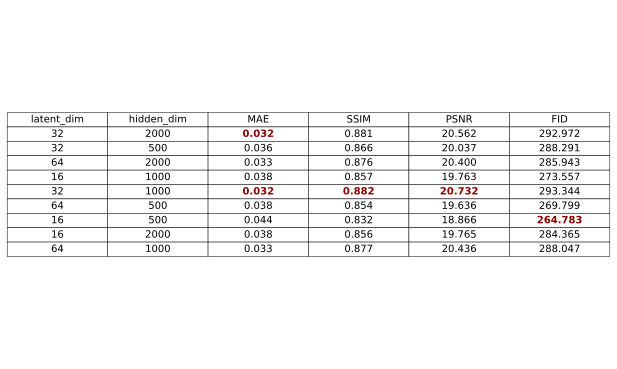

<Figure size 640x480 with 0 Axes>

In [14]:
# --- Extract latent_dim and hidden_dim from Experiment column ---
if not "latent_dim" in results_df.columns or not "hidden_dim" in results_df.columns:
    exp_info = results_df["Experiment"].str.split("_", expand=True)

    # (based on your folder name pattern: e.g., 'exp_zdim_16_hdim_128_lr_...')
    results_df["latent_dim"] = exp_info[2].astype(int)
    results_df["hidden_dim"] = exp_info[5].astype(int)

# Keep only compact columns
results_df = results_df[["latent_dim", "hidden_dim", "MAE", "SSIM", "PSNR", 
                         "FID"
                         ]]

# Format floats to 3 decimals (as strings for display)
formatted_df = results_df.copy()
for col in ["MAE", "SSIM", "PSNR", 
            "FID"
            ]:
    formatted_df[col] = results_df[col].map(lambda x: f"{x:.3f}")

# Round floats to 3 decimals
formatted_df = formatted_df.round(3)

# Define which metrics to maximize / minimize
best_by = {
    "MAE": "min",   # Lower is better
    "SSIM": "max",  # Higher is better
    "PSNR": "max",  # Higher is better
    "FID": "min",   # Lower is better
}

# Plot table with bolded best results per metric
fig, ax = plt.subplots(figsize=(9, len(formatted_df) * 0.6 + 1))
ax.axis("off")

mpl_table = ax.table(
    cellText=formatted_df.values,
    colLabels=formatted_df.columns,
    cellLoc="center",
    loc="center",
)

# Adjust font/scale
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(10)
mpl_table.scale(1.2, 1.2)

# Bold best values per column
for j, metric in enumerate(formatted_df.columns[2:], start=2):  # metrics start at col 2
    if best_by[metric] == "max":
        best_val = formatted_df[metric].max()
    else:
        best_val = formatted_df[metric].min()

    for i in range(len(formatted_df)):
        cell = mpl_table.get_celld()[(i + 1, j)]
        if formatted_df.iloc[i, j] == best_val:
            cell.set_text_props(weight="bold", color="darkred")

plt.show()

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

## Random Sample Comparison



This block compares the generative capabilities of two selected models: a high-performing one (`z_dim=32`, `hidden_dim=1000`) and a lower-performing one (`z_dim=16`, `hidden_dim=500`). It generates new font glyphs by sampling random points from each model's latent space and passing them through the decoder. The resulting images are displayed side-by-side to visually compare the quality, diversity, and coherence of the generated samples. The top row shows samples from the better model, and the bottom row shows samples from the weaker model.

✅ Saved random sample comparison into random_sample_comparison.png


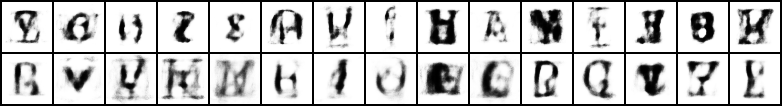

In [15]:
# from the experiments_done folder, pick two experiments to compare
# get latent_dim 32 and hidden_dim 1000 (the best one)
# get latent_dim 16 and hidden_dim 500 (a worse one)

exp1 = [d for d in experiment_dirs if "z_dim_32" in d and "hidden_dim_1000" in d][0]
exp2 = [d for d in experiment_dirs if "z_dim_16" in d and "hidden_dim_500" in d][0]

def generate_random_samples(model, z_dim, n_samples, device):
    """Generate random samples from model using latent normal distribution."""
    latents = torch.randn(n_samples, z_dim).to(device)
    with torch.no_grad():
        samples = model.decode(latents).cpu()
    return samples

def show_random_sample_comparison(exp1, exp2, img_size, n=8):
    """
    Compare random samples from two experiments that have different z_dim.
    Generates n samples for each experiment using its own latent space.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    def load_and_sample(exp_dir, n):
        parts = os.path.basename(exp_dir).split('_')
        z_dim, hidden_dim = int(parts[2]), int(parts[5])
        
        model = VAE(z_dim=z_dim, hidden_dim=hidden_dim, img_size=img_size).to(device)
        model.load_state_dict(
            torch.load(os.path.join(exp_dir, "models", "best_model.pth"),
                       map_location=device)
        )
        model.eval()
        
        return generate_random_samples(model, z_dim, n, device)
    
    samples1 = load_and_sample(exp1, n)
    samples2 = load_and_sample(exp2, n)
    
    # Combine grid: [Exp1 row | Exp2 row]
    comparison = torch.cat([samples1, samples2])
    
    save_image(
        comparison, "random_sample_comparison.png", nrow=n
    )
    print("✅ Saved random sample comparison into random_sample_comparison.png")

# Compare Exp1 vs Exp2
show_random_sample_comparison(
    exp1=exp1,
    exp2=exp2,
    img_size=base_config["img_size"],
    n=15
)

Image.open("sample_comparison.png")

## Reconstruction Comparison

This section visually compares the reconstruction quality of the same two models. It uses a fixed, consistent batch of images from the validation set as input for both. The output image displays a grid with three rows:

1.  **Top Row**: The original, ground-truth images.

2.  **Middle Row**: The reconstructions from the better-performing model.

3.  **Bottom Row**: The reconstructions from the weaker model.

This direct comparison makes it easy to spot differences in sharpness, detail preservation, and overall accuracy between the two architectures.

✅ Fixed batch saved!
Tensor shapes - Real: torch.Size([20, 1, 50, 50]), Recon1: torch.Size([20, 1, 50, 50]), Recon2: torch.Size([20, 1, 50, 50])
✅ Saved unified comparison: comparison.png


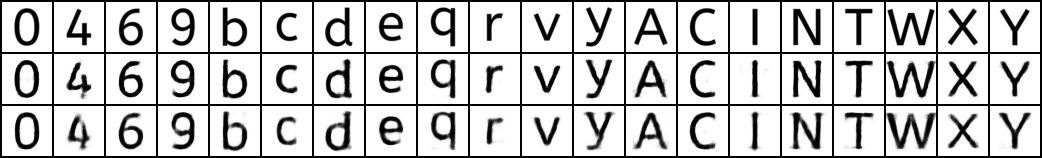

In [17]:
val_loader_eval = create_eval_dataloader(base_config)

# Save the SAME batch of validation images for consistent comparison
fixed_batch, _ = next(iter(val_loader_eval))
torch.save(fixed_batch, "fixed_batch.pt")
print("✅ Fixed batch saved!")

def show_reconstruction_comparison(fixed_batch, exp1, exp2, img_size, n=8):
    """Show a grid: [real | exp1 fake | exp2 fake] for n samples."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    fixed_batch = fixed_batch.to(device)[:n]

    # Load models
    def load_and_reconstruct(exp_dir):
        parts = os.path.basename(exp_dir).split('_')
        z_dim, hidden_dim = int(parts[2]), int(parts[5])
        model = VAE(z_dim=z_dim, hidden_dim=hidden_dim, img_size=img_size).to(device)
        model.load_state_dict(torch.load(os.path.join(exp_dir, "models", "best_model.pth"), 
                                         map_location=device))
        model.eval()
        with torch.no_grad():
            recon, _, _ = model(fixed_batch)

        recon = recon.view(-1, 1, img_size, img_size)
        return recon.cpu()

    recon1 = load_and_reconstruct(exp1)
    recon2 = load_and_reconstruct(exp2)

    print(f"Tensor shapes - Real: {fixed_batch.shape}, Recon1: {recon1.shape}, Recon2: {recon2.shape}")

    # Make comparison tensor
    comparison = torch.cat([
        fixed_batch.cpu(), recon1, recon2
    ])
    
    save_image(
        comparison, "comparison.png", nrow=n
    )
    print("✅ Saved unified comparison: comparison.png")

show_reconstruction_comparison(fixed_batch, exp1, exp2, base_config["img_size"], n=20)

Image.open("comparison.png")

# Discussion

## Analysis of Quantitative Results
The evaluation metrics summarized in the results table offer a comprehensive view of each model's performance. A key finding is the inverse relationship between reconstruction quality and generative quality, as measured by FID. The model with the best reconstruction scores, showing the lowest MAE and highest SSIM and PSNR, was the configuration with a latent dimension of 32 and a hidden dimension of 1000 or 2000. Conversely, the model with the best (lowest) FID score was the one with the smallest capacity, using a latent dimension of 16 and a hidden dimension of 500, which also happened to have the worst reconstruction metrics. This trade-off is fundamental to VAEs, as a larger model can more easily capture fine details for accurate reconstruction, while a smaller model is forced by its information bottleneck to learn a more generalized and smoother latent representation that benefits novel generation.

The latent dimension's role as an information bottleneck was evident. A low latent_dim of 16 struggled with reconstruction, lacking the capacity to encode necessary details. A medium latent_dim of 32 appeared to be the sweet spot, achieving the best balance of capturing essential features without being so large that it failed to regularize the latent space effectively. A high latent_dim of 64 did not consistently outperform the latent_dim=32 models, suggesting diminishing returns.

Similarly, the hidden dimension determines the network's overall capacity. As expected, increasing the hidden_dim from 500 to 2000 consistently improved reconstruction metrics across all latent dimensions. A larger network is better able to learn the complex mappings between the image and latent spaces. However, this increased capacity generally led to worse FID scores, reinforcing the reconstruction-generation trade-off.

---

## Analysis of Qualitative Results

Visual inspection of the generated and reconstructed glyphs provides context that quantitative metrics alone cannot.

**Reconstruction Quality:**
The reconstruction comparison image starkly illustrates the quantitative findings.
* The **better-performing model** (`latent_dim=32`, `hidden_dim=1000`) produces reconstructions that are sharp and faithful to the ground-truth samples. Edges are well-defined, and character integrity is maintained.
* The **weaker model** (`latent_dim=16`, `hidden_dim=500`) yields noticeably blurry and less precise reconstructions. This blurriness is a well-known artifact of VAEs, as the model learns to output an "average" of possibilities when uncertain, a direct consequence of minimizing reconstruction loss on a pixel-wise basis.



**Generative Quality:**
The random sample comparison reveals the nuances of "generative quality."
* The **better-performing model** (top row) generates glyphs that are sharper and more defined, in comparison to the weaker model. However, the generated characters still fail to capture the form and sharpness of real font glyphs, indicating that while the model has learned some structural features, it has not fully mastered the complexity of font design. 
* The **weaker model** (bottom row) produces softer, blurrier, and less distinct shapes. Although its FID score was superior, the visual quality is arguably lower. This suggests that the FID metric, while powerful, may favor "safer," more average-looking samples that are statistically closer to the real data distribution in feature space over sharper but potentially more flawed or less diverse samples.

# Limitations and Future Work

This study successfully demonstrates the capabilities of a simple VAE, but several limitations and avenues for improvement exist:

1.  **Architecture:** The use of a fully-connected (MLP) architecture is suboptimal for image data. Future work should employ a **Convolutional Neural Network (CNN)** for the encoder and decoder. CNNs are designed to respect the spatial hierarchy of pixels and would almost certainly reduce blurriness and improve feature extraction, leading to higher-quality results.
2.  **VAE Variants:** The characteristic blurriness could be further addressed by exploring more advanced models like **Vector-Quantized VAEs (VQ-VAEs)** or **Generative Adversarial Networks (GANs)**, which are known for producing sharper images.
3.  **Regularization:** The trade-off between reconstruction and generation could be more explicitly controlled by using a **β-VAE**, which introduces a tunable hyperparameter (β) to weigh the KL divergence term in the loss function, allowing for a better balance between the two objectives.